LINEAR REGRESSION

In [12]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# Convert to pandas DataFrame if needed:
boston_df = pd.DataFrame(data, columns=feature_names)
boston_df['PRICE'] = target

print(boston_df.head())


      CRIM    ZN  INDUS  CHAS    NOX  ...    TAX  PTRATIO       B  LSTAT  PRICE
0  0.00632  18.0   2.31   0.0  0.538  ...  296.0     15.3  396.90   4.98   24.0
1  0.02731   0.0   7.07   0.0  0.469  ...  242.0     17.8  396.90   9.14   21.6
2  0.02729   0.0   7.07   0.0  0.469  ...  242.0     17.8  392.83   4.03   34.7
3  0.03237   0.0   2.18   0.0  0.458  ...  222.0     18.7  394.63   2.94   33.4
4  0.06905   0.0   2.18   0.0  0.458  ...  222.0     18.7  396.90   5.33   36.2

[5 rows x 14 columns]


In [13]:
print(boston_df.shape)

print(boston_df.columns)

(506, 14)
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')


In [17]:
X = boston_df.drop('PRICE', axis=1)
Y = boston_df['PRICE']

print(boston_df['PRICE'])

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64


In [20]:
from sklearn.model_selection import train_test_split

# Assuming X has 506 rows and 13 features (like the Boston housing dataset) and Y is target
# test_size=0.33 splits the data into 339 training rows and 167 testing rows (67% / 33% split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=5)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(339, 13)
(167, 13)
(339,)
(167,)


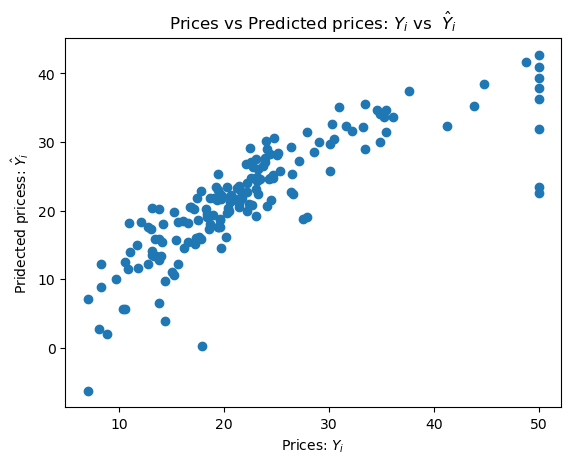

In [24]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

lm= LinearRegression()
lm.fit(X_train, Y_train)

Y_pred = lm.predict(X_test)

plt.scatter(Y_test, Y_pred)
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Pridected pricess: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs  $\hat{Y}_i$ ")
plt.show()

C:\Users\achal\AppData\Local\Temp\ipykernel_2552\2157418367.py:7: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.05`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.

  sns.kdeplot(np.array(delta_y), bw= 0.05)


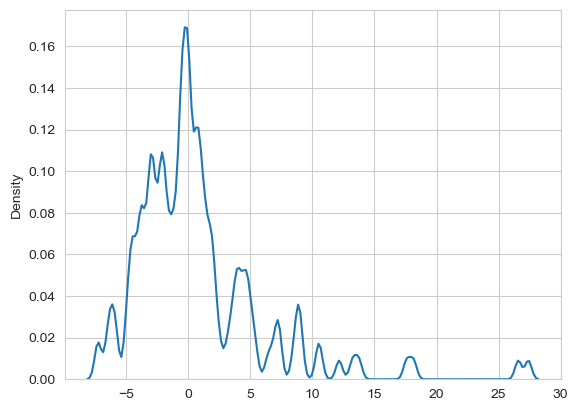

C:\Users\achal\AppData\Local\Temp\ipykernel_2552\2157418367.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.05`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.

  sns.kdeplot(np.array(Y_pred), bw= 0.05)


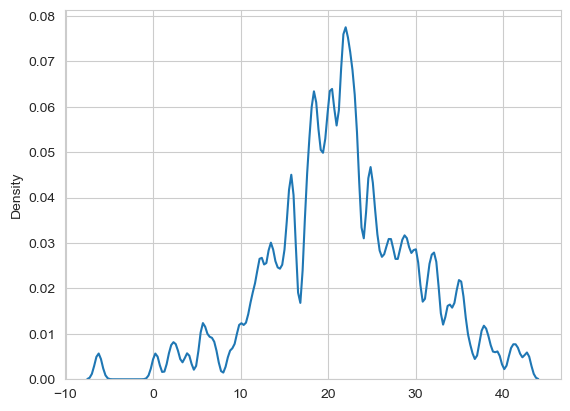

In [37]:
delta_y = Y_test - Y_pred

import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
sns.kdeplot(np.array(delta_y), bw= 0.05)
plt.show() 

sns.set_style("whitegrid")
sns.kdeplot(np.array(Y_pred), bw= 0.05)
plt.show() 